In [1]:
from tl_tools import *
from residual_stream_collection_tools import format_prompt

torch.set_grad_enabled(False)

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = load_llama8br1()

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  7.32it/s]


Loaded model and tokenizer from local cache.
Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer


In [3]:
format_prompt(model, "Whats the fifth prime?", "immediate_answer")

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n\n</think>\n\n'

Q: what is going on with 2, 17's attention map?

something to note, is that the attention map here is essentially identically on its own position 

Let's see if we can understand what's happening by working backwards 

layer 2) the output here 

If so, we could just apply the OV to the input, to try to understand what about this output is so important 

there are kind of multiple questions here

1) what is the vector that is injected in when we apply the ov circuit to the resid pre

2) what is it about the key output of this head that alligns so well with its own query?

again, we start at layer 2 

suppose we have 

1) what about the value of the /n/n token that the attention map is drawn to?


It 

In [4]:
model.W_Q[2, 17].shape

torch.Size([4096, 128])

In [5]:
model.OV[2, 17].shape

torch.Size([4096, 4096])

In [6]:
# extract the

In [7]:
def generate_with_attention(
    model: HookedTransformer,
    prompt: str,
    heads: list[tuple[int,int]],
    max_new_tokens: int = 50,
    do_sample: bool = False,
    temperature: float = 0.6
) -> dict[str, str | list[str] | list[int] | int | dict[tuple[int,int], np.ndarray]]:
    """
    Generate text and capture the FINAL attention patterns (softmax) for specified heads.
    Reconstructs a full (prompt+generated)×(prompt+generated) matrix for each head.
    """
    model.eval()

    # 1) Validate
    for layer, head in heads:
        if not (0 <= layer < model.cfg.n_layers):
            raise ValueError(f"Layer {layer} out of range")
        if not (0 <= head < model.cfg.n_heads):
            raise ValueError(f"Head {head} out of range")

    # 2) Storage for the raw per-step tensors
    raw_attn: dict[tuple[int,int], list[torch.Tensor]] = {h: [] for h in heads}

    # 3) Hook factory capturing attn.hook_pattern
    def make_hook(layer: int, head: int):
        def hook_fn(attn: torch.Tensor, **kwargs):
            # attn shape = (1, n_heads, Q, K)
            raw_attn[(layer, head)].append(attn[0, head].cpu().clone())
            return attn
        return hook_fn

    # 4) Install hooks and remember handles
    for layer, head in heads:
        name = f"blocks.{layer}.attn.hook_pattern"
        model.add_hook(name, make_hook(layer, head))

    # 5) Tokenize + generate (uses KV cache under the hood)
    tokens = model.to_tokens(prompt, prepend_bos=True)  # (1, L_prompt)
    gen = model.generate(
        tokens,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
        eos_token_id=model.tokenizer.eos_token_id,
    )  # (1, L_prompt+L_gen)

    # 6) Teardown hooks
    model.reset_hooks()

    # 7) Decode text & tokens
    token_ids = gen[0].cpu().tolist()
    generated_text = model.tokenizer.decode(token_ids)
    str_tokens = [model.tokenizer.decode([tid]) for tid in token_ids]
    n_generated = gen.shape[1] - tokens.shape[1]

    # 8) Reconstruct full attention matrix per head
    full_attn: dict[tuple[int,int], np.ndarray] = {}
    for layer_head, attn_list in raw_attn.items():
        # attn_list[0] is the prompt-only pass: shape (L_prompt, L_prompt)
        # subsequent attn_list[i] are shape (1, L_prompt + i)
        L_prompt = attn_list[0].shape[0]
        L_gen = len(attn_list) - 1
        L_total = L_prompt + L_gen

        M = np.zeros((L_total, L_total), dtype=float)
        # fill prompt×prompt
        M[:L_prompt, :L_prompt] = attn_list[0].numpy()
        # fill each generated token’s row
        for i, step_attn in enumerate(attn_list[1:], start=1):
            row = step_attn[0].numpy()  # shape (L_prompt + i,)
            M[L_prompt + i - 1, : L_prompt + i] = row

        full_attn[layer_head] = M

    return {
        "generated_text": generated_text,
        "tokens": str_tokens,
        "token_ids": token_ids,
        "n_generated": n_generated,
        "attention_weights": full_attn,
    }

In [8]:
prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    prompt,
    heads=[(2, 17)],
    max_new_tokens=20,
    do_sample=False
)

100%|██████████| 20/20 [00:09<00:00,  2.22it/s]


In [8]:
from typing import Dict, Any, Tuple

def plot_single_attention_detailed(
    attention_data: Dict[str, Any], 
    step_to_plot: int = -1,
    figsize: Tuple[int, int] = (14, 12),
    colormap: str = 'hot'
) -> None:
    """
    Plot a single attention matrix with detailed token labels and enhanced visibility.
    
    Args:
        attention_data: Result from generate_and_return_attention
        step_to_plot: Which step to plot (-1 for last step)
        figsize: Figure size
        colormap: Colormap to use ('hot', 'afmhot', 'gist_heat', 'copper' are good options)
    """
    
    attention_weights = attention_data["attention_weights"]
    tokens = attention_data["tokens"]
    
    if len(attention_weights) == 0:
        print("No attention weights captured!")
        return
    
    if step_to_plot == -1:
        step_to_plot = len(attention_weights) - 1
    
    if step_to_plot >= len(attention_weights):
        print(f"Step {step_to_plot} not available. Max step: {len(attention_weights)-1}")
        return
    
    attn_matrix = attention_weights[step_to_plot]
    attn_np = attn_matrix.numpy()
    seq_len = attn_np.shape[0]
    step_tokens = tokens[:seq_len]
    
    # Create figure with proper spacing
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Use colormap where 0 is black and slight differences are clearly visible
    im = ax.imshow(attn_np, cmap=colormap, aspect='equal', vmin=0, vmax=1)
    
    # Set ticks and labels - show ALL token strings
    tick_positions = list(range(len(step_tokens)))
    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(step_tokens, rotation=45, ha='right', fontsize=max(8, min(12, 100//seq_len)))
    ax.set_yticklabels(step_tokens, fontsize=max(8, min(12, 100//seq_len)))
    
    # Add title and labels with proper positioning
    ax.set_title(f'Attention Matrix - Step {step_to_plot+1} (seq_len={seq_len})', 
                fontsize=16, pad=25, loc='center')
    ax.set_xlabel('Keys (tokens being attended TO)', fontsize=13)
    ax.set_ylabel('Queries (tokens attending FROM)', fontsize=13)
    
    # Add colorbar with better positioning
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Attention Weight', rotation=270, labelpad=20, fontsize=12)
    
    # Add grid for better readability
    ax.set_xticks(np.arange(-0.5, len(step_tokens), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(step_tokens), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5, alpha=0.7)
    
    # Add text annotations for high attention values (optional)
    max_val = np.max(attn_np)
    if max_val > 0.1:  # Only annotate if there are significant attention weights
        high_attention_threshold = max_val * 0.8
        for i in range(seq_len):
            for j in range(seq_len):
                if attn_np[i, j] > high_attention_threshold:
                    ax.text(j, i, f'{attn_np[i,j]:.2f}', 
                           ha='center', va='center', 
                           color='white' if attn_np[i,j] > 0.5 else 'black',
                           fontsize=8, fontweight='bold')
    
    # Ensure proper layout and centering
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.15, left=0.15, right=0.9)  # Make room for labels and title
    plt.show()
    
    # Print some statistics
    print(f"\nAttention Statistics for Step {step_to_plot+1}:")
    print(f"Matrix shape: {attn_np.shape}")
    print(f"Max attention: {np.max(attn_np):.4f}")
    print(f"Min attention: {np.min(attn_np):.4f}")
    print(f"Mean attention: {np.mean(attn_np):.4f}")
    print(f"Tokens: {step_tokens}")


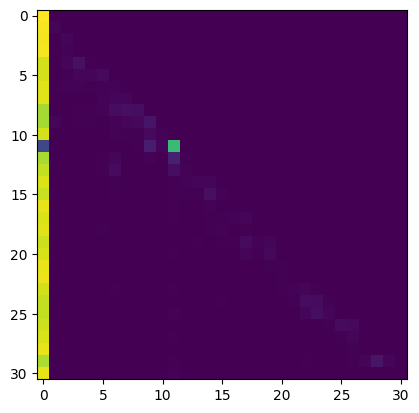

In [10]:
plt.imshow(out["attention_weights"][2, 17])

100%|██████████| 20/20 [00:12<00:00,  1.66it/s]


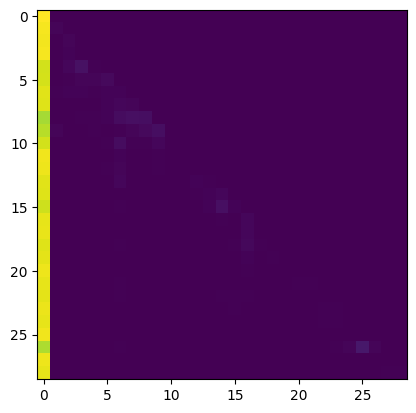

In [12]:
prompt = format_prompt(model, "Whats the fifth prime?", "reason")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    prompt,
    heads=[(2, 17)],
    max_new_tokens=20,
    do_sample=False
)

plt.imshow(out["attention_weights"][2, 17])

POssible mechanism 

2, 17 is either attending to \n\n following stop think if answering 

or 

bos if reasoning 

In [9]:
def analyze_head_attention_sources(model, head, prompt: str, source_idx: int):
    """
    Analyze what this head's OV circuit would contribute from one specific source position.
    
    Args:
        model: HookedTransformer model
        head: (layer_idx, head_idx) tuple  
        prompt: Input prompt
        source_idx: The source position to analyze (can be negative for indexing from end)
        
    Returns:
        dict: Single contribution result
    """
    
    layer_idx, head_idx = head
    captured_resid_pre = None
    
    def hook_resid_pre(activation, hook):
        nonlocal captured_resid_pre
        captured_resid_pre = activation.detach().clone()
        return activation
    
    model.add_hook(f"blocks.{layer_idx}.hook_resid_pre", hook_resid_pre)
    
    try:
        # Tokenize with explicit BOS control
        tokens = model.to_tokens(prompt, prepend_bos=True)
        
        with torch.no_grad():
            _ = model.forward(tokens)
        
        # Handle negative indexing
        seq_len = captured_resid_pre.shape[1]
        if source_idx < 0:
            source_idx = seq_len + source_idx
            
        # Get OV matrix directly from TransformerLens
        W_OV = model.OV[layer_idx, head_idx]  # (d_model, d_model)
        
        # Compute contribution from the specific source position
        source_resid = captured_resid_pre[0, source_idx, :]
        contribution = source_resid @ W_OV
        
        # Get token string for this position  
        token_strings = model.to_str_tokens(tokens[0])  # Use the same tokenized input
        
        result = {
            'vector': contribution,
            'norm': torch.norm(contribution).item(),
            'token': token_strings[source_idx],
            'source_idx': source_idx
        }

        print("target_token = ",token_strings[source_idx])
        
        return result
        
    finally:
        model.reset_hooks()

# let's pull out the BOS token processed by 2, 17

In [10]:
format_prompt(model, "Whats the fifth prime?", "immediate_answer")

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n\n</think>\n\n'

In [11]:
bos_values = analyze_head_attention_sources(
    model, 
    (2, 17), 
    prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer"),
    source_idx = 0
)

final_nn_values = analyze_head_attention_sources(
    model, 
    (2, 17), 
    prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer"),
    source_idx = -1
)

target_token =  <｜begin▁of▁sentence｜>
target_token =  




In [16]:
bos_values['vector'].shape

torch.Size([4096])

In [17]:
bos_values

{'vector': tensor([-0.0590, -0.0174, -0.0003,  ...,  0.1975, -0.0500, -0.0566],
        device='cuda:0'),
 'norm': 5.085511684417725,
 'token': '<｜begin▁of▁sentence｜>',
 'source_idx': 0}

In [18]:
final_nn_values

{'vector': tensor([ 0.0058,  0.0003,  0.0061,  ..., -0.0010,  0.0044,  0.0031],
        device='cuda:0'),
 'norm': 0.18945305049419403,
 'token': '\n\n',
 'source_idx': 11}

Question: What happens when I wipe out (2, 17)?

lets generate with both prompts, with that head killed off 

In [12]:
import torch

def simple_patch_generate(
    patch_prompt: str,
    target_heads: list[tuple[int, int]] | tuple[int, int],
    base_prompt: str | None = None,
    max_new_tokens: int = 50,
    scale: float = 1.0,
    injection_tensor: torch.Tensor | None = None,
    temp: float | None = None,
) -> str:
    """
    Simplified two-stage head patching:
      1. If base_prompt is provided, run it once to grab each head's final z-output.
         If base_prompt is None, we’ll disable those heads (zero them) instead.
      2. Generate on patch_prompt, but at the final prompt token index
         override each target head’s z with either the saved vector*scale or zero.
      3. If injection_tensor is given, also add it into attention-out at that same position.

    Args:
        patch_prompt:      The prompt you actually want to generate from.
        target_heads:      One (layer, head) tuple or a list thereof.
        base_prompt:       The prompt to extract “correct” heads from, or None to zero them.
        max_new_tokens:    How many new tokens to sample after patching.
        scale:             Multiplicative factor on saved head activations.
        injection_tensor:  A (d_model,) tensor to add into attn.out at the patch position.
    Returns:
        The decoded string from the patched generation.
    """
    # — normalize heads —
    if isinstance(target_heads, tuple):
        heads: list[tuple[int, int]] = [target_heads]
    else:
        heads = target_heads
    
    # for each head, assert that the first token is not a bos token
    if base_prompt is not None:
        assert model.to_tokens(base_prompt, prepend_bos=False)[0, 0] != model.tokenizer.bos_token_id, "Base prompt must not start with BOS token"
    assert model.to_tokens(patch_prompt, prepend_bos=False)[0, 0] != model.tokenizer.bos_token_id, "Patch prompt must not start with BOS token"

    # — Stage 1: collect base z’s if requested —
    stored_z: Dict[tuple[int, int], torch.Tensor] = {}

    if base_prompt is not None:
        # hook each layer’s attn.z to grab only the last token
        for layer_idx, head_idx in heads:
            hook_name = f"blocks.{layer_idx}.attn.hook_z"
            def make_save(layer_idx: int, head_idx: int):
                def save_hook(z: torch.Tensor, hook=None) -> torch.Tensor:
                    # z: (1, seq_len, n_heads, head_dim)
                    stored_z[(layer_idx, head_idx)] = (
                        z[0, -1, head_idx, :].detach().cpu().clone()
                    )
                    return z
                return save_hook
            fn = make_save(layer_idx, head_idx)
            model.add_hook(hook_name, fn)

        # run base_prompt through the model (no new tokens needed)
        tokens = model.to_tokens(base_prompt, prepend_bos=True)
        
        # collect the final z values
        with torch.no_grad():
            _ = model.forward(tokens)
        
        # we've collected the z values, so we can remove the hooks
        model.reset_hooks()

    # — Stage 2: install patch hooks for z —
    # precompute prompt length
    tokens_patch = model.to_tokens(patch_prompt, prepend_bos=True)
    prompt_len = tokens_patch.shape[1]
    for layer_idx, head_idx in heads:
        hook_name = f"blocks.{layer_idx}.attn.hook_z"
        def make_patch(layer_idx: int, head_idx: int):
            def patch_hook(z: torch.Tensor, hook=None) -> torch.Tensor:
                # only override at the final prompt index
                # z: (1, seq_len, n_heads, head_dim)
                if z.shape[1] == prompt_len:
                    if base_prompt is None:
                        z[0, -1, head_idx, :] *= 0.0
                    else:
                        vec = stored_z[(layer_idx, head_idx)].to(z.device) * scale
                        z[0, -1, head_idx, :] = vec
                return z
            return patch_hook
        
        fn = make_patch(layer_idx, head_idx)
        model.add_hook(hook_name, fn)

    # — optional: injection into attention output —
    if injection_tensor is not None:
        for layer_idx, _ in heads:
            hook_name = f"blocks.{layer_idx}.hook_resid_mid"
            def make_inject():
                def inject_hook(out: torch.Tensor, hook=None) -> torch.Tensor:
                    # out: (1, seq_len, d_model)
                    if out.shape[1] == prompt_len:
                        out[0, -1, :] += injection_tensor.to(out.device)
                    return out
                return inject_hook
            fn = make_inject()
            model.add_hook(hook_name, fn)

    # — run patched generation —
    result = model.generate(
        patch_prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False if temp is None else True,
        temperature=temp,
    )

    # clean up all hooks
    model.reset_hooks()
    return result


In [13]:
reason_prompt = format_prompt(model, "Whats the fifth prime?", "reason")

immediate_answer_prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer")

print(reason_prompt)
print(immediate_answer_prompt)



<｜User｜>Whats the fifth prime?<｜Assistant｜><think>

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>

</think>




Let's first try triggering reasoning and triggering answering 

In [20]:
out1 = simple_patch_generate(
    patch_prompt=reason_prompt,
    target_heads=[(2, 17),],
    base_prompt=immediate_answer_prompt,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = None,
)

out2 = simple_patch_generate(
    patch_prompt=immediate_answer_prompt,
    target_heads=[(2, 17),],
    base_prompt=reason_prompt,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = None,
)

  2%|▏         | 9/500 [00:00<00:39, 12.32it/s]


Now let's try setting the heads to zero

In [25]:
out1 = simple_patch_generate(
    patch_prompt=reason_prompt,
    target_heads=[(2, 17),],
    base_prompt=None,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = None,
)

out2 = simple_patch_generate(
    patch_prompt=immediate_answer_prompt,
    target_heads=[(2, 17),],
    base_prompt=None,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = None,
)

  0%|          | 0/500 [00:00<?, ?it/s]

  2%|▏         | 9/500 [00:00<00:39, 12.45it/s]


In [26]:
print(out1)

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>
To determine the fifth prime number, I'll start by listing the prime numbers in order.

First, I know that 2 is the smallest and only even prime number.

Next, 3 is the second prime number.

Then, 5 comes after 3 as the third prime.

After that, 7 is the fourth prime number.

Finally, 11 is the fifth prime number.
</think>

**Solution:**

A **prime number** is a natural number greater than 1 that has no positive divisors other than 1 and itself.

Let's list the prime numbers in order:

1. **2** (the first prime number)
2. **3** (the second prime number)
3. **5** (the third prime number)
4. **7** (the fourth prime number)
5. **11** (the fifth prime number)

**Final Answer:**
\boxed{11}


In [27]:
print(out2)

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>
</think>

The fifth prime number is **11**.


Now, let's try injecting the quantities I extracted -- these are the (2, 17) OV head applied to the BOS residual stream, and the \n\n resid

In [28]:
bos_values['vector']

tensor([-0.0590, -0.0174, -0.0003,  ...,  0.1975, -0.0500, -0.0566],
       device='cuda:0')

In [99]:
out_reason = simple_patch_generate(
    patch_prompt=reason_prompt,
    target_heads=[(2, 17),],
    base_prompt=reason_prompt,
    max_new_tokens = 500,
    scale = 1,
    injection_tensor = None,
)

out_reason_with_bos_2_17_OV_injection = simple_patch_generate(
    patch_prompt=reason_prompt,
    target_heads=[(2, 17),],
    base_prompt=None,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = 5*bos_values['vector']/bos_values['vector'].norm(dim=0),
)

out_reason_with_nn_2_17_OV_injection = simple_patch_generate(
    patch_prompt=reason_prompt,
    target_heads=[(2, 17),],
    base_prompt=None,
    max_new_tokens = 500,
    scale = 1.4,
    injection_tensor = 5*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
)

 16%|█▌        | 79/500 [00:05<00:30, 13.71it/s]


In [101]:
print(out_reason_with_nn_2_17_OV_injection)

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>
The fifth prime number is **11**. Here’s the list of prime numbers in order:

1. **2** (the first prime)
2. **3** (the second prime)
3. **5** (the third prime)
4. **7** (the fourth prime)
5. **11** (the fifth prime)

Let me know if you'd like further clarification!


lets see if this can be used as a reason knob

In [21]:
immediate_answer_prompt

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n</think>\n\n'

In [24]:
import numpy as np
import pickle
from pathlib import Path
from typing import Any, Union


class GenerationCollector:
    """
    Collects generation outputs along with associated knob values and lengths,
    and supports saving to and loading from disk.
    """

    def __init__(self, filepath: Union[str, Path]) -> None:
        self.knob_values: list[float] = []
        self.outputs: list[Any] = []
        self.lengths: list[int] = []
        self.filepath: Path = Path(filepath)
        # Ensure directory exists
        if not self.filepath.parent.exists():
            self.filepath.parent.mkdir(parents=True, exist_ok=True)

    def add(self, knob_value: float, output: Any, length: int) -> None:
        """
        Add a new generation result and save to disk.
        """
        self.knob_values.append(knob_value)
        self.outputs.append(output)
        self.lengths.append(length)
        self.save()

    def save(self, filepath: Union[str, Path] | None = None) -> None:
        """
        Save the collector data to disk via pickle.
        """
        target = Path(filepath) if filepath is not None else self.filepath
        with target.open("wb") as f:
            pickle.dump({
                'knob_values': self.knob_values,
                'outputs': self.outputs,
                'lengths': self.lengths
            }, f)

    @classmethod
    def load(cls, filepath: Union[str, Path]) -> "GenerationCollector":
        """
        Load a collector from disk and return a new instance.
        """
        target = Path(filepath)
        with target.open("rb") as f:
            data = pickle.load(f)

        collector = cls(filepath=target)
        collector.knob_values = data.get('knob_values', [])
        collector.outputs = data.get('outputs', [])
        collector.lengths = data.get('lengths', [])
        return collector

In [ ]:
# Define sweep and output collector
reason_knob_values = np.linspace(0, 5, 10)
output_file = "reason_prompt_reason_vector_sweep.pkl"
collector = GenerationCollector(filepath=output_file)

# Run sweep
for rep in range(50):
    for knob_value in reason_knob_values:
        out = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=1,
            injection_tensor=(knob_value * bos_values['vector'] / bos_values['vector'].norm(dim=0)),
            temp=0.6,
        )
        length = len(model.to_str_tokens(out))
        collector.add(knob_value, out, length)

print(f"Results saved to {output_file}")

 16%|█▌        | 155/1000 [00:11<01:02, 13.57it/s]

In [ ]:
reason_knob_values = np.linspace(0, 5, 10)
output_file = "reason_prompt_answer_vector_sweep.pkl"
collector = GenerationCollector(filepath=output_file)

# Run sweep using nested rep then knob_value loops
for rep in range(50):
    for knob_value in reason_knob_values:
        current_out = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=1.0,
            injection_tensor = knob_value*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
            temp=0.6,
        )
        length = len(model.to_str_tokens(current_out))
        collector.add(knob_value, current_out, length)

print(f"Results saved to {output_file}")




  0%|          | 0/1000 [00:00<?, ?it/s]

  6%|▋         | 64/1000 [00:04<01:08, 13.72it/s]

In [57]:
reason_knob_values = np.linspace(0, 5, 10)
output_file = "reason_prompt_answer_vector_sweep.pkl"
collection = []
lengths = []

# Run sweep using nested rep then knob_value loops
for rep in range(1):
    for knob_value in reason_knob_values:
        current_out = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=1.0,
            injection_tensor = knob_value*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
            temp=None,
        )
        length = len(model.to_str_tokens(current_out))
        lengths.append(length)
        collection.append(current_out)

print(f"Results saved to {output_file}")

  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|          | 9/1000 [00:01<03:04,  5.36it/s]

Results saved to reason_prompt_answer_vector_sweep.pkl


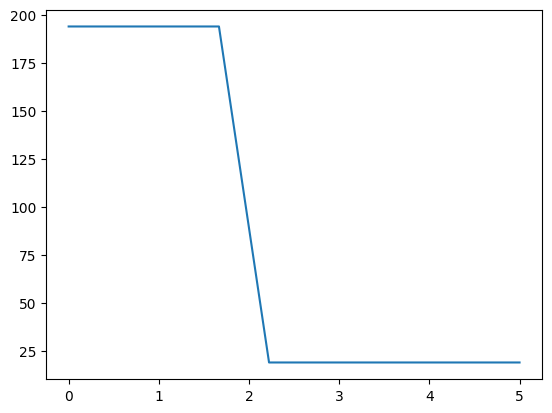

In [59]:
plt.plot(reason_knob_values, lengths)

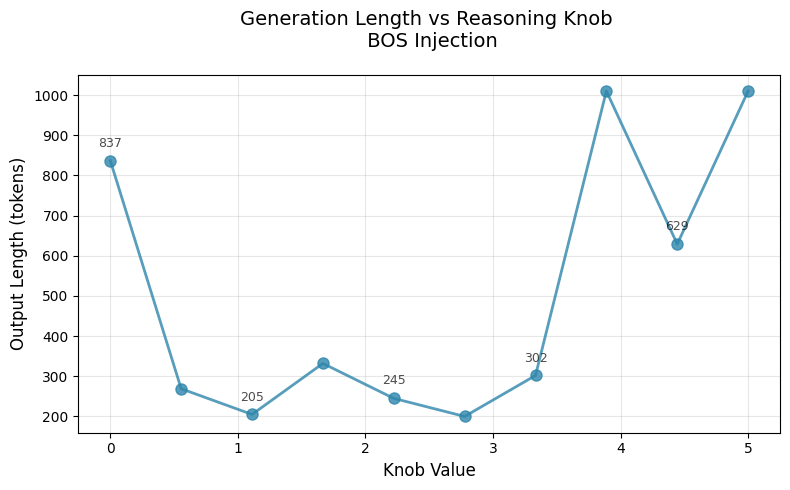

In [ ]:

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(all_knob_values, all_out_lengths, 'o-', 
         color='#2E86AB', linewidth=2, markersize=8, alpha=0.8)

# Styling
plt.xlabel('Knob Value', fontsize=12)
plt.ylabel('Output Length (tokens)', fontsize=12)
plt.title('Generation Length vs Reasoning Knob \n BOS Injection', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Optional: Add value annotations for key points
for i in range(0, len(all_knob_values), 2):  # Every other point
    plt.annotate(f'{all_out_lengths[i]}', 
                (all_knob_values[i], all_out_lengths[i]),
                textcoords="offset points", xytext=(0,10), ha='center',
                fontsize=9, alpha=0.7)

plt.show()

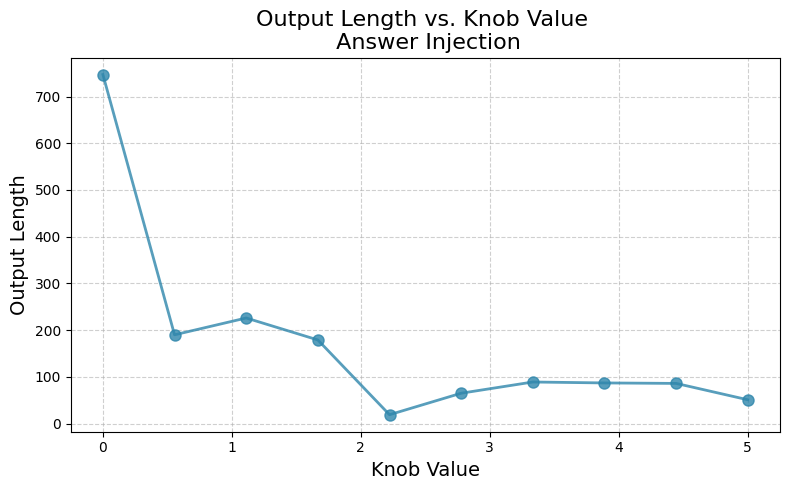

In [108]:
# create other plot 
plt.figure(figsize=(8, 5))
plt.plot(all_knob_values_answer, all_out_lengths_answer, 'o-', 
         color='#2E86AB', linewidth=2, markersize=8, alpha=0.8)
plt.xlabel('Knob Value', fontsize=14)
plt.ylabel('Output Length', fontsize=14)
plt.title('Output Length vs. Knob Value \n Answer Injection', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

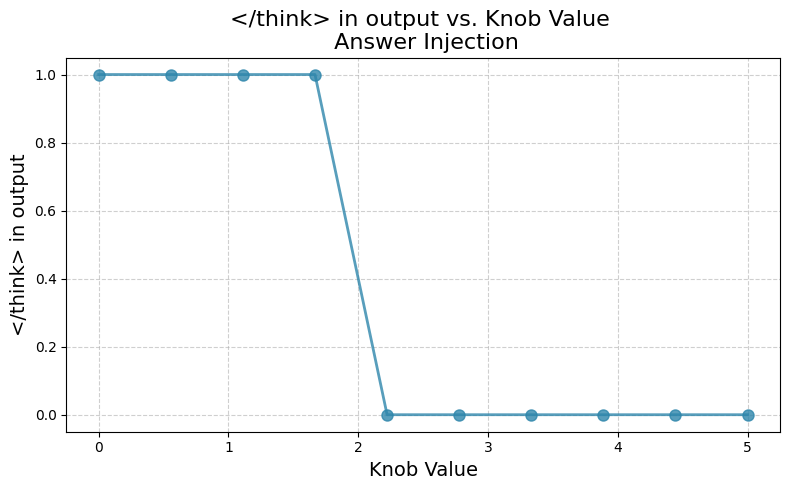

In [112]:
# create other plot 
plt.figure(figsize=(8, 5))
plt.plot(all_knob_values_answer, ["</think>" in out for out in all_outs_answer], 'o-', 
         color='#2E86AB', linewidth=2, markersize=8, alpha=0.8)
plt.xlabel('Knob Value', fontsize=14)
plt.ylabel('</think> in output', fontsize=14)
plt.title('</think> in output vs. Knob Value \n Answer Injection', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

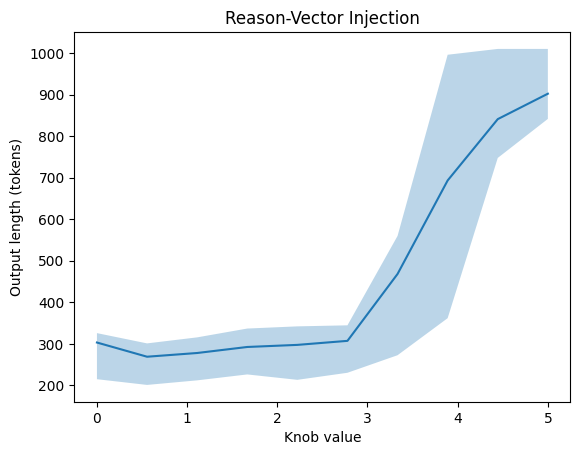

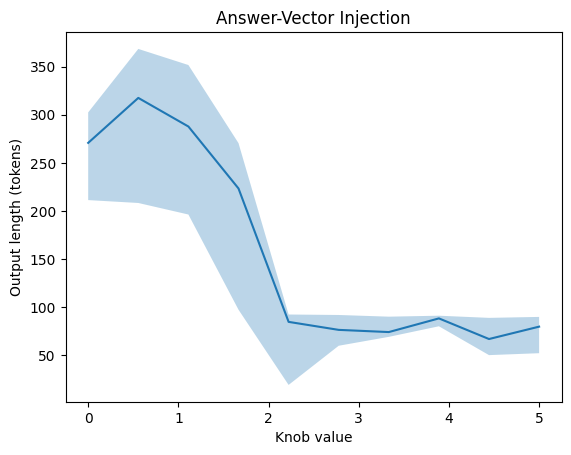

In [4]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def plot_length_vs_knob(pickle_path: str, title: str) -> None:
    # Load saved data
    data: dict[str, list[float] | list[int]] = pickle.load(open(pickle_path, 'rb'))
    knob_values: np.ndarray = np.array(data['knob_values'], dtype=float)
    lengths:    np.ndarray = np.array(data['lengths'],      dtype=int)

    # Aggregate by unique knob
    unique_knobs: np.ndarray = np.unique(knob_values)
    means:  np.ndarray = np.array([lengths[knob_values == k].mean()       for k in unique_knobs])
    p25:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 25) for k in unique_knobs])
    p75:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 75) for k in unique_knobs])

    # Plot
    plt.plot(unique_knobs, means)
    plt.fill_between(unique_knobs, p25, p75, alpha=0.3)
    plt.xlabel('Knob value')
    plt.ylabel('Output length (tokens)')
    plt.title(title)
    plt.show()

plot_length_vs_knob('reason_prompt_reason_vector_sweep_20250626.pkl', "Reason-Vector Injection")
plot_length_vs_knob('reason_prompt_answer_vector_sweep_20250626.pkl', "Answer-Vector Injection")

In [14]:
def plot_length_vs_knob(pickle_path: str, title: str) -> None:
    # Load saved data
    data: dict[str, list[float] | list[int]] = pickle.load(open(pickle_path, 'rb'))
    knob_values: np.ndarray = np.array(data['knob_values'], dtype=float)
    lengths:    np.ndarray = np.array(data['lengths'],      dtype=int)

    # Aggregate by unique knob
    unique_knobs: np.ndarray = np.unique(knob_values)
    means:  np.ndarray = np.array([lengths[knob_values == k].mean()       for k in unique_knobs])
    p25:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 25) for k in unique_knobs])
    p75:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 75) for k in unique_knobs])

    # Plot
    plt.plot(unique_knobs, means)
    plt.fill_between(unique_knobs, p25, p75, alpha=0.3)
    plt.xlabel('Knob value')
    plt.ylabel('Output length (tokens)')
    plt.title(title)
    plt.show()


In [15]:
def plot_length_vs_knob(pickle_path: str, title: str) -> None:
    # Load saved data
    data: dict[str, list[float] | list[int]] = pickle.load(open(pickle_path, 'rb'))
    knob_values: np.ndarray = np.array(data['knob_values'], dtype=float)
    lengths:    np.ndarray = np.array(data['lengths'],      dtype=int)

    # Aggregate by unique knob
    unique_knobs: np.ndarray = np.unique(knob_values)
    means:  np.ndarray = np.array([lengths[knob_values == k].mean()       for k in unique_knobs])
    p25:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 25) for k in unique_knobs])
    p75:    np.ndarray = np.array([np.percentile(lengths[knob_values == k], 75) for k in unique_knobs])

    # Plot
    plt.plot(unique_knobs, means)
    plt.fill_between(unique_knobs, p25, p75, alpha=0.3)
    plt.xlabel('Knob value')
    plt.ylabel('Output length (tokens)')
    plt.title(title)
    plt.show()


In [16]:
# what's the cosine similarity between the final nn values and the bos values?

def cosine_similarity(a, b):
    # a torch tensor, b a torch tensor
    return torch.nn.functional.cosine_similarity(a, b, dim=0)

cosine_similarity(final_nn_values['vector'], bos_values['vector'])

tensor(0.0013, device='mps:0')

In [97]:
# whats the norm of each of the final nn values?

final_nn_values['vector'].norm(dim=0), bos_values['vector'].norm(dim=0)



(tensor(0.1895, device='cuda:0'), tensor(5.0855, device='cuda:0'))

In [81]:
utils.get_act_name("result", model.blocks[2].attn)

'blocks.GroupedQueryAttention(\n  (hook_k): HookPoint()\n  (hook_q): HookPoint()\n  (hook_v): HookPoint()\n  (hook_z): HookPoint()\n  (hook_attn_scores): HookPoint()\n  (hook_pattern): HookPoint()\n  (hook_result): HookPoint()\n  (hook_rot_k): HookPoint()\n  (hook_rot_q): HookPoint()\n).attn.hook_result'

Let's sweep over intensities with which we inject these values 

In [109]:
reason_prompt

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n'

In [110]:
immediate_answer_prompt

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n</think>\n\n'

In [76]:
model

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out)

In [ ]:
print(out1)

In [69]:
print(out2)

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>
</think>

The fifth prime number is **11**.


In [17]:

def analyze_attention_svd(model, layer_idx: int, head_idx: int, analyze_combined: bool = True):
    """
    Perform SVD analysis on attention matrices for a specific head.
    
    Args:
        model: HookedTransformer model
        layer_idx: Layer index
        head_idx: Head index  
        analyze_combined: Whether to also analyze the combined QK^T operation
    
    Returns:
        Dictionary containing SVD results for W_Q, W_K, and optionally combined matrices
    """
    
    # Extract the weight matrices
    W_Q = model.W_Q[layer_idx, head_idx]  # Shape: (d_model, d_head)
    W_K = model.W_K[layer_idx, head_idx]  # Shape: (d_model, d_head)
    
    print(f"W_Q shape: {W_Q.shape}")
    print(f"W_K shape: {W_K.shape}")
    
    results = {}
    
    # SVD of W_Q
    U_q, S_q, Vh_q = torch.linalg.svd(W_Q, full_matrices=False)
    results['W_Q'] = {
        'U': U_q,      # Shape: (4096, 128) - left singular vectors
        'S': S_q,      # Shape: (128,) - singular values
        'Vh': Vh_q,    # Shape: (128, 128) - right singular vectors
        'matrix': W_Q
    }
    
    # SVD of W_K  
    U_k, S_k, Vh_k = torch.linalg.svd(W_K, full_matrices=False)
    results['W_K'] = {
        'U': U_k,      # Shape: (4096, 128)
        'S': S_k,      # Shape: (128,)
        'Vh': Vh_k,    # Shape: (128, 128)
        'matrix': W_K
    }
    
    print(f"W_Q singular values shape: {S_q.shape}")
    print(f"W_K singular values shape: {S_k.shape}")
    print(f"Number of singular values for each: {len(S_q)}")
    
    if analyze_combined:
        # Analyze the combined QK^T matrix
        # This represents the bilinear form: x^T W_Q W_K^T y
        QK_combined = W_Q @ W_K.T  # Shape: (4096, 4096)
        
        print(f"Combined QK^T shape: {QK_combined.shape}")
        
        # SVD of combined matrix
        U_combined, S_combined, Vh_combined = torch.linalg.svd(QK_combined, full_matrices=False)
        results['QK_combined'] = {
            'U': U_combined,
            'S': S_combined,
            'Vh': Vh_combined,
            'matrix': QK_combined
        }
        
        print(f"Combined matrix singular values shape: {S_combined.shape}")
        print(f"Combined matrix rank (approx): {torch.sum(S_combined > 1e-6).item()}")
    
    return results

def plot_singular_values(results, layer_idx: int, head_idx: int, log_scale: bool = True):
    """Plot singular values for comparison."""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot W_Q singular values
    S_q = results['W_Q']['S'].cpu().numpy()
    axes[0].plot(S_q, 'b-', alpha=0.7)
    axes[0].set_title(f'W_Q Singular Values\nLayer {layer_idx}, Head {head_idx}')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Singular Value')
    if log_scale:
        axes[0].set_yscale('log')
    
    # Plot W_K singular values
    S_k = results['W_K']['S'].cpu().numpy()
    axes[1].plot(S_k, 'r-', alpha=0.7)
    axes[1].set_title(f'W_K Singular Values\nLayer {layer_idx}, Head {head_idx}')
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('Singular Value')
    if log_scale:
        axes[1].set_yscale('log')
    
    # Plot combined singular values if available
    if 'QK_combined' in results:
        S_combined = results['QK_combined']['S'].cpu().numpy()
        axes[2].plot(S_combined[:200], 'g-', alpha=0.7)  # Plot first 200 for visibility
        axes[2].set_title(f'QK^T Combined Singular Values\nLayer {layer_idx}, Head {head_idx}')
        axes[2].set_xlabel('Index')
        axes[2].set_ylabel('Singular Value')
        if log_scale:
            axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

def compute_effective_rank(singular_values, threshold: float = 0.01):
    """
    Compute effective rank based on singular value threshold.
    
    Args:
        singular_values: Tensor of singular values
        threshold: Relative threshold (fraction of largest singular value)
    
    Returns:
        Effective rank (number of singular values above threshold)
    """
    max_sv = torch.max(singular_values)
    effective_rank = torch.sum(singular_values > threshold * max_sv).item()
    return effective_rank

def analyze_head_ranks(model, layer_idx: int, head_idx: int):
    """Analyze the ranks and structure of attention matrices."""
    
    results = analyze_attention_svd(model, layer_idx, head_idx, analyze_combined=True)
    
    # Compute effective ranks
    rank_q = compute_effective_rank(results['W_Q']['S'])
    rank_k = compute_effective_rank(results['W_K']['S'])
    
    print(f"\n=== Rank Analysis for Layer {layer_idx}, Head {head_idx} ===")
    print(f"W_Q effective rank: {rank_q} / {len(results['W_Q']['S'])}")
    print(f"W_K effective rank: {rank_k} / {len(results['W_K']['S'])}")
    
    if 'QK_combined' in results:
        rank_combined = compute_effective_rank(results['QK_combined']['S'])
        theoretical_max_rank = min(rank_q, rank_k)
        print(f"Combined QK^T effective rank: {rank_combined} / {len(results['QK_combined']['S'])}")
        print(f"Theoretical max rank for combined: {theoretical_max_rank}")
        print(f"Rank efficiency: {rank_combined / theoretical_max_rank:.3f}")
    
    # Analyze singular value decay
    S_q = results['W_Q']['S']
    S_k = results['W_K']['S']
    
    print(f"\nSingular value ratios (largest/smallest):")
    print(f"W_Q: {S_q[0] / S_q[-1]:.2e}")
    print(f"W_K: {S_k[0] / S_k[-1]:.2e}")
    
    return results

# Example usage functions:

def compare_heads_svd(model, layer_idx: int, head_indices: list):
    """Compare SVD properties across multiple heads in the same layer."""
    
    head_results = {}
    
    for head_idx in head_indices:
        print(f"\n{'='*50}")
        print(f"Analyzing Layer {layer_idx}, Head {head_idx}")
        print(f"{'='*50}")
        
        results = analyze_attention_svd(model, layer_idx, head_idx, analyze_combined=False)
        head_results[head_idx] = results
        
        # Quick stats
        rank_q = compute_effective_rank(results['W_Q']['S'])
        rank_k = compute_effective_rank(results['W_K']['S'])
        
        print(f"Head {head_idx} - W_Q rank: {rank_q}, W_K rank: {rank_k}")
    
    return head_results

def get_low_rank_approximation(matrix, k: int):
    """
    Get rank-k approximation of a matrix using SVD.
    
    Args:
        matrix: Input matrix
        k: Target rank
    
    Returns:
        Rank-k approximation of the matrix
    """
    U, S, Vh = torch.linalg.svd(matrix, full_matrices=False)
    
    # Keep only top k singular values
    U_k = U[:, :k]
    S_k = S[:k]
    Vh_k = Vh[:k, :]
    
    # Reconstruct
    approximation = U_k @ torch.diag(S_k) @ Vh_k
    
    return approximation, (U_k, S_k, Vh_k)

# Example usage:
"""
# Analyze a specific head
layer_idx, head_idx = 2, 17
results = analyze_head_ranks(model, layer_idx, head_idx)

# Plot the results
plot_singular_values(results, layer_idx, head_idx)

# Compare multiple heads
head_results = compare_heads_svd(model, layer_idx, [15, 16, 17, 18, 19])

# Get low-rank approximation
W_Q = model.W_Q[2, 17]
approx_rank_10, (U_k, S_k, Vh_k) = get_low_rank_approximation(W_Q, k=10)
reconstruction_error = torch.norm(W_Q - approx_rank_10).item()
print(f"Rank-10 approximation error: {reconstruction_error}")
"""

'\n# Analyze a specific head\nlayer_idx, head_idx = 2, 17\nresults = analyze_head_ranks(model, layer_idx, head_idx)\n\n# Plot the results\nplot_singular_values(results, layer_idx, head_idx)\n\n# Compare multiple heads\nhead_results = compare_heads_svd(model, layer_idx, [15, 16, 17, 18, 19])\n\n# Get low-rank approximation\nW_Q = model.W_Q[2, 17]\napprox_rank_10, (U_k, S_k, Vh_k) = get_low_rank_approximation(W_Q, k=10)\nreconstruction_error = torch.norm(W_Q - approx_rank_10).item()\nprint(f"Rank-10 approximation error: {reconstruction_error}")\n'

# Experiment 

For tokens following the final prompt token 

they must have the information that they are answering transferred to them 

Do they look at the \n\n token?

Here's an experiment:

[reason base][answer]

[answer base][answer]

Then we can see which heads attend to that position 

OR 

here's an idea

as we increase the answer injection into that token 

which heads have attention maps which increase the attention paid to that position 



In [18]:
import torch
import torch.nn.functional as F
import numpy as np
from transformer_lens import HookedTransformer

def injection_and_attn_sweep(
    model: HookedTransformer,
    prompt: str,
    token_idx: int,
    injection_vector: torch.Tensor,
    scale: float = 1.0,
    target_head: tuple[int, int] = (2, 17),
    attention_token_idx=None,
) -> dict[str, dict[tuple[int, int], float] | str | float]:
    """
    Kill & inject on one head, then sweep upward layers for avg attention-to-injection_idx,
    and compute mean log-probabilities of tokens after that index.

    Returns:
        {
          "avg_attn_weights": {(layer, head): avg_weight, …},
          "injected_token":   str,
          "post_token_log_probs": float
        }
    """
    if attention_token_idx is None:
        attention_token_idx=token_idx
    # 1) Tokenize
    tokens = model.to_tokens(prompt, prepend_bos=True)  # (1, L)
    seq_len = tokens.shape[1]
    token_ids = tokens[0].tolist()
    str_tokens = [model.tokenizer.decode([tid]) for tid in token_ids]
    injected_token = str_tokens[token_idx]

    # 2) Storage for all captured attention
    raw_attn: dict[tuple[int, int], torch.Tensor] = {}
    targ_layer, targ_head = target_head

    # 3a) Hook to kill the head's pre-attn z at token_idx
    def kill_z(z: torch.Tensor, hook=None) -> torch.Tensor:
        if z.shape[1] == seq_len:
            z[0, token_idx, targ_head, :] = 0.0
        return z

    # 3b) Hook to inject into the residual stream at token_idx
    def inject_resid_mid(resid_mid: torch.Tensor, hook=None) -> torch.Tensor:
        if resid_mid.shape[1] == seq_len:
            resid_mid[0, token_idx, :] += injection_vector.to(resid_mid.device) * scale
        return resid_mid

    # 3c) Hook factory to capture final softmax attention patterns
    def make_capture(layer: int, head: int):
        def capture(attn: torch.Tensor, **kwargs):
            raw_attn[(layer, head)] = attn[0, head].cpu()
            return attn
        return capture

    # 4) Install hooks
    model.add_hook(f"blocks.{targ_layer}.attn.hook_z", kill_z)
    model.add_hook(f"blocks.{targ_layer}.hook_resid_mid", inject_resid_mid)

    for layer in range(targ_layer + 1, model.cfg.n_layers):
        for head in range(model.cfg.n_heads):
            model.add_hook(
                f"blocks.{layer}.attn.hook_pattern",
                make_capture(layer, head),
            )

    # 5) Forward pass to get logits and then log-probs
    loss = 0
    with torch.no_grad():
        loss -= model(tokens[:, :token_idx+1], return_type="loss")
        loss += model(tokens, return_type="loss")  # (1, L, vocab_size)

    # 6) Teardown hooks
    model.reset_hooks()

    # 7) Compute average attention *to* token_idx *from* positions > token_idx
    avg_attn_weights: dict[tuple[int, int], float] = {}
    for (layer, head), attn_mat in raw_attn.items():
        if attention_token_idx + 1 < attn_mat.shape[0]:
            col = attn_mat[attention_token_idx + 1 :, attention_token_idx]
            avg_attn_weights[(layer, head)] = float(col.mean().item())
        else:
            avg_attn_weights[(layer, head)] = 0.0

    # 8) Compute mean ce-loss of the *actual* tokens after token_idx
    mean_post_loss = float(loss)

    # 9) Return everything
    return {
        "avg_attn_weights": avg_attn_weights,
        "injected_token": injected_token,
        "post_token_loss": mean_post_loss,
    }


In [19]:
reason_prompt = format_prompt(model, "Whats the fifth prime?", "reason")

immediate_answer_prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer")

print(reason_prompt)
print(immediate_answer_prompt)

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>

<｜User｜>Whats the fifth prime?<｜Assistant｜><think>

</think>




In [20]:
input_prompt = reason_prompt+"The fifth prime number is **11**.<｜end▁of▁sentence｜>"

In [21]:
print(model.to_str_tokens(input_prompt)[9])
print(model.to_str_tokens(input_prompt)[0])



<｜begin▁of▁sentence｜>


In [22]:
scale_values = np.linspace(0, 5, 50)

all_head_attention_weights = {}
all_log_probs = []
all_scale_values = []

for scale in scale_values:
    cur_results = injection_and_attn_sweep(
        model=model,
        prompt=input_prompt,
        token_idx=9,
        injection_vector=scale*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
        scale = 1,
        target_head= (2, 17),
    )
    assert cur_results['injected_token'] == '\n'
    # collect attention 
    for head_tuple, value in cur_results["avg_attn_weights"].items():
        if head_tuple not in all_head_attention_weights:
            all_head_attention_weights[head_tuple] = []
        all_head_attention_weights[head_tuple].append(value)
    
    all_log_probs.append(cur_results['post_token_loss'])

    all_scale_values.append(scale)
    

In [23]:
import matplotlib.pyplot as plt
from typing import Any, Callable

def plot_attention_and_logprob(
    scale_values: list[float],
    all_head_attention_weights: dict[tuple[int, int], list[float]],
    all_log_probs: list[float],
    shift: bool = False
) -> None:
    """
    Creates two separate plots:
    1) All head attention weights vs. scale.
    2) Mean post-token log probabilities vs. scale.

    Args:
        scale_values: List of scale factors used.
        all_head_attention_weights: Mapping from (layer, head) to list of attention weights.
        all_log_probs: List of mean log probabilities following the target token.
        shift: If True, shift each head's attention series so that at scale=0 it starts at 0.
    """
    # Plot 1: Attention weights for each head
    plt.figure()
    for (layer, head), weights in all_head_attention_weights.items():
        weights_to_plot = [
            w - weights[0] if shift else w
            for w in weights
        ]
        plt.plot(scale_values, weights_to_plot, label=f"Layer {layer}, Head {head}", alpha=0.5)
    plt.xlabel("Scale")
    plt.ylabel("Attention Weight" + (" (shifted)" if shift else ""))
    plt.title("Attention Weights vs. Scale")
    #plt.legend()
    plt.tight_layout()

    # Plot 2: Mean post-token log probabilities
    plt.figure()
    plt.plot(scale_values, all_log_probs)
    plt.xlabel("Scale")
    plt.ylabel("Mean Post-Token Loss")
    plt.title("Mean Post-Token Loss vs. Scale")
    plt.tight_layout()

# Example usage:
# plot_attention_and_logprob(all_scale_values, all_head_attention_weights, all_log_probs, shift=False)



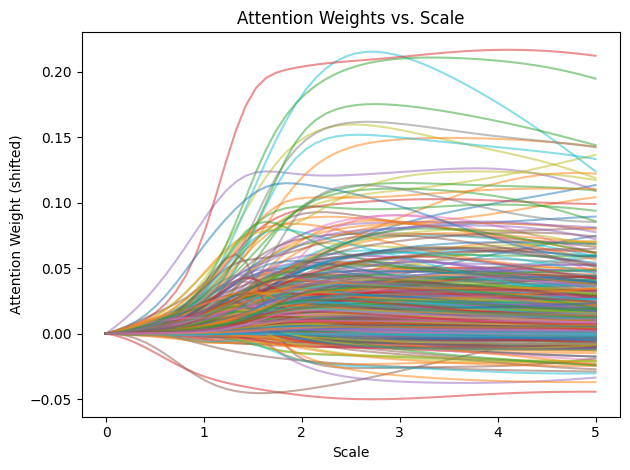

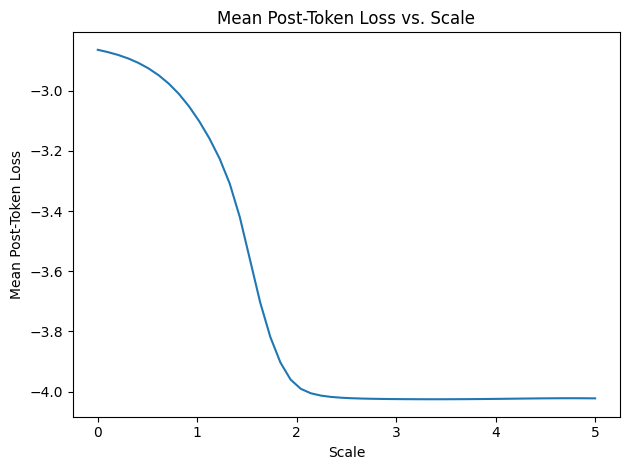

In [24]:
plot_attention_and_logprob(
    scale_values=all_scale_values,
    all_head_attention_weights=all_head_attention_weights,
    all_log_probs=all_log_probs,
    shift=True  # or True if you want to zero at scale=0
)

# here's what i want to to

take the top responding heads 

and see where they attend during reasoning alone



# lets' do this for the bos vector

In [151]:
input_prompt

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\nThe fifth prime number is **11**.<｜end▁of▁sentence｜>'

In [56]:
reason_text = "<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\nTo determine the fifth prime number, I'll start by"

In [57]:
model.to_str_tokens(reason_text)[9]

'\n'

In [58]:
scale_values = np.linspace(0, 5, 50)

bos_inj_all_head_attention_weights = {}
bos_inj_all_log_probs = []
bos_inj_all_scale_values = []

for scale in scale_values:
    cur_results = injection_and_attn_sweep(
        model=model,
        prompt=reason_text,
        token_idx=9,
        injection_vector=scale*bos_values['vector']/bos_values['vector'].norm(dim=0),
        scale = 1,
        target_head= (2, 17),
        attention_token_idx=11
    )
    assert cur_results['injected_token'] == '\n'
    # collect attention 
    for head_tuple, value in cur_results["avg_attn_weights"].items():
        if head_tuple not in bos_inj_all_head_attention_weights:
            bos_inj_all_head_attention_weights[head_tuple] = []
        bos_inj_all_head_attention_weights[head_tuple].append(value)
    
    bos_inj_all_log_probs.append(cur_results['post_token_loss'])

    bos_inj_all_scale_values.append(scale)
    

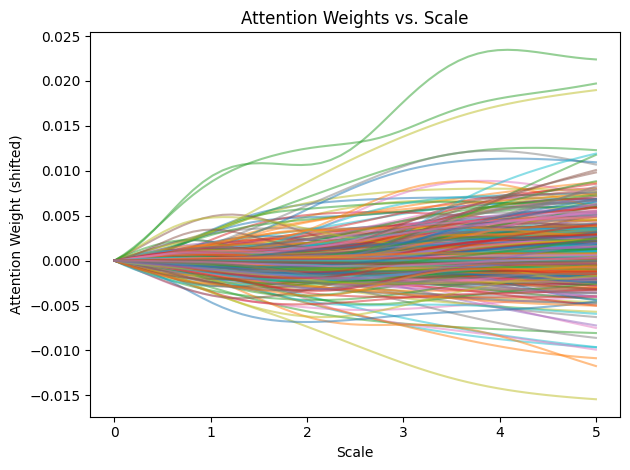

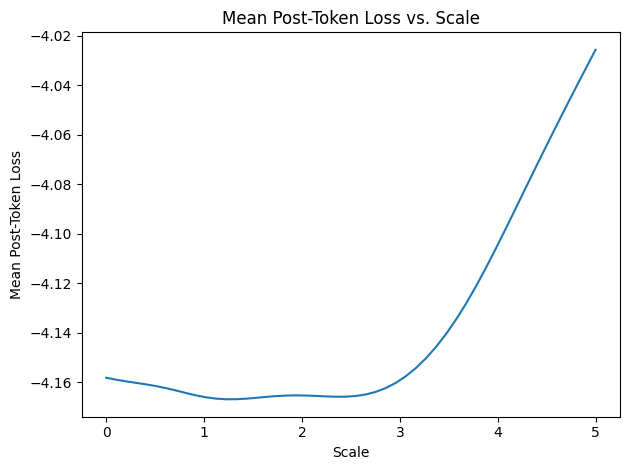

In [59]:
plot_attention_and_logprob(
    scale_values=bos_inj_all_scale_values,
    all_head_attention_weights=bos_inj_all_head_attention_weights,
    all_log_probs=bos_inj_all_log_probs,
    shift=True  # or True if you want to zero at scale=0
)

# now let's plot this 

I want to see the change plotted 

which heads attend the most as we sweep from scale =0 to scale =target_scale

top 10 heads: 
(15, 5):  0.21285193413496017
(22, 5):  0.21086318418383598
(18, 12):  0.20960192009806633
(30, 18):  0.1744995415210724
(16, 31):  0.16050046309828758
(11, 2):  0.15609160624444485
(16, 13):  0.15004204586148262
(13, 31):  0.14801582135260105
(11, 18):  0.1230689138174057
(29, 16):  0.11871270090341568


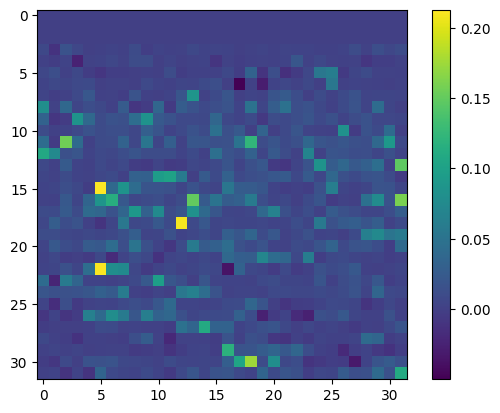

In [25]:
def plot_attention_change(all_head_attention_weights, all_scale_values, target_scale = 3):
    attention_weights = np.zeros((32, 32))
    assert all_scale_values[0] == 0
    target_index = np.argmin(np.abs(np.array(all_scale_values) - target_scale))

    vals = []

    for (layer, head), weights in all_head_attention_weights.items():
        attention_weights[layer][head] = weights[target_index] - weights[0]
        vals.append((weights[target_index] - weights[0], (layer, head)))
    
    plt.imshow(attention_weights)

    plt.colorbar()

    vals.sort(reverse=True)

    top_n = 10
    print(f"top {top_n} heads: ")
    for i in range(min(10, len(vals))):
        print(f"{vals[i][-1]}:  {vals[i][0]}")

    return zip(*vals)

    


vals, heads = plot_attention_change(all_head_attention_weights, all_scale_values, target_scale = 3)

In [26]:
heads

((15, 5),
 (22, 5),
 (18, 12),
 (30, 18),
 (16, 31),
 (11, 2),
 (16, 13),
 (13, 31),
 (11, 18),
 (29, 16),
 (16, 6),
 (31, 31),
 (27, 14),
 (12, 0),
 (30, 17),
 (14, 11),
 (23, 10),
 (14, 10),
 (17, 8),
 (11, 30),
 (7, 13),
 (16, 5),
 (9, 3),
 (15, 7),
 (13, 24),
 (9, 9),
 (17, 13),
 (10, 26),
 (8, 0),
 (30, 20),
 (22, 6),
 (26, 6),
 (16, 29),
 (17, 10),
 (22, 7),
 (12, 1),
 (19, 29),
 (21, 19),
 (12, 23),
 (17, 20),
 (26, 4),
 (24, 13),
 (19, 28),
 (15, 25),
 (26, 9),
 (5, 25),
 (21, 23),
 (24, 7),
 (19, 31),
 (16, 18),
 (26, 7),
 (23, 2),
 (14, 12),
 (20, 13),
 (18, 24),
 (6, 25),
 (24, 12),
 (5, 24),
 (18, 7),
 (15, 16),
 (11, 9),
 (20, 8),
 (19, 30),
 (16, 15),
 (11, 17),
 (8, 18),
 (8, 21),
 (27, 12),
 (10, 15),
 (16, 28),
 (12, 15),
 (13, 29),
 (22, 4),
 (20, 16),
 (9, 8),
 (24, 14),
 (15, 8),
 (11, 0),
 (20, 6),
 (8, 29),
 (21, 20),
 (23, 0),
 (10, 30),
 (28, 28),
 (31, 29),
 (11, 3),
 (17, 4),
 (26, 5),
 (17, 14),
 (25, 11),
 (20, 31),
 (15, 6),
 (11, 29),
 (9, 4),
 (17, 19),
 

Interesting...

Let's look at the attention maps at some of these strongest attending heads

In [28]:
prompt = format_prompt(model, "Whats the fifth prime?", "immediate_answer")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    prompt,
    heads=heads[:10],
    max_new_tokens=20,
    do_sample=False
)

100%|██████████| 20/20 [00:04<00:00,  4.72it/s]


In [33]:
total_mean_map = sum(out['attention_weights'].values())/len(out['attention_weights'])

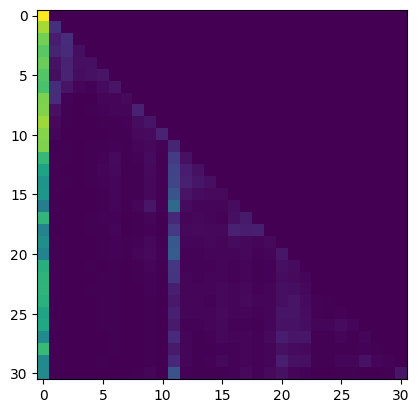

In [34]:
plt.imshow(total_mean_map)

100%|██████████| 20/20 [00:04<00:00,  4.94it/s]


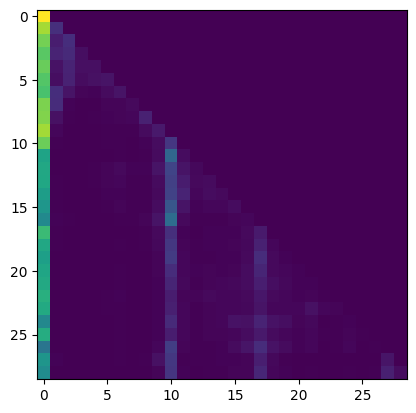

In [52]:
reason_prompt = format_prompt(model, "Whats the fifth prime?", "reason")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    reason_prompt,
    heads=heads[:10],
    max_new_tokens=20,
    do_sample=False
)

total_mean_map_r = sum(out['attention_weights'].values())/len(out['attention_weights'])

plt.imshow(total_mean_map_r)

In [53]:
out['tokens'][10]

'To'

100%|██████████| 20/20 [00:04<00:00,  4.97it/s]


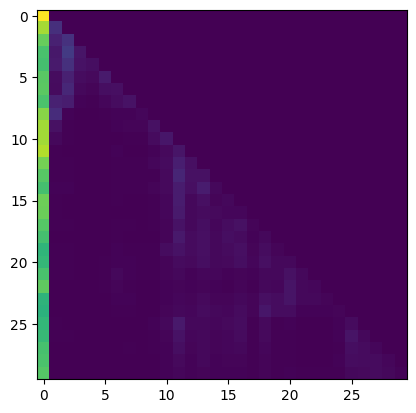

In [49]:
reason_prompt = format_prompt(model, "Why is the sky blue?", "reason")

# 2. Run generation + attention capture
out = generate_with_attention(
    model,
    reason_prompt,
    heads=heads[:10],
    max_new_tokens=20,
    do_sample=False
)

total_mean_map_r = sum(out['attention_weights'].values())/len(out['attention_weights'])

plt.imshow(total_mean_map_r)

In [50]:
out['tokens'][11], out['tokens'][23], 

('Okay', ' is')

In [51]:
out['tokens'][10]

'\n'

In [118]:
out.keys()

dict_keys(['generated_text', 'tokens', 'token_ids', 'n_generated', 'attention_weights'])

In [131]:
len(out['tokens'])

32

In [148]:
out_r['generated_text']

"<｜begin▁of▁sentence｜><｜User｜>Whats the fifth prime?<｜Assistant｜><think>\nTo determine the fifth prime number, I'll start by listing the prime numbers in order.\n\nFirst,"

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


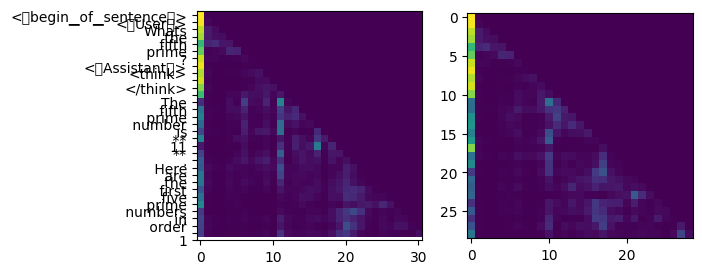

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


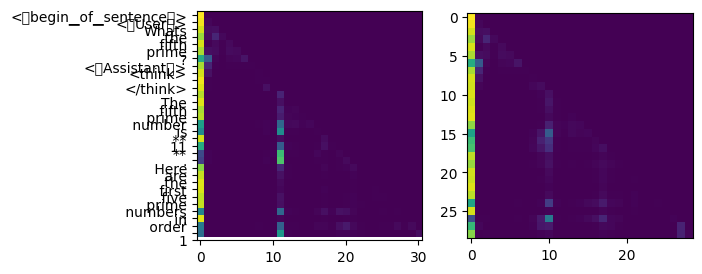

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


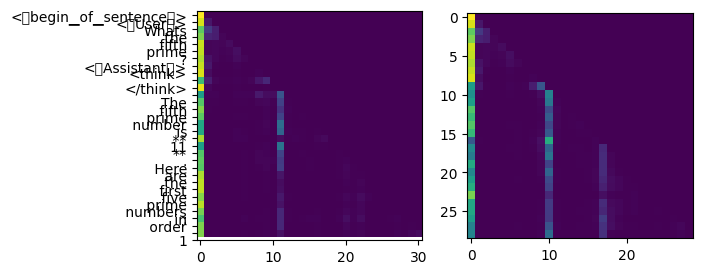

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


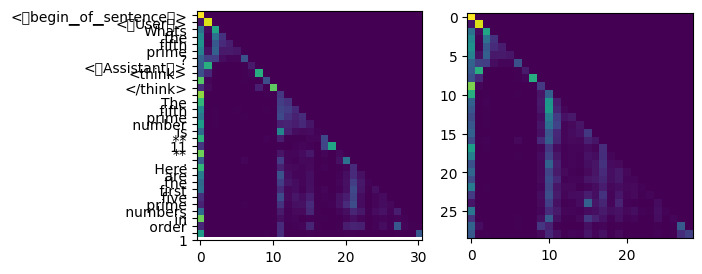

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


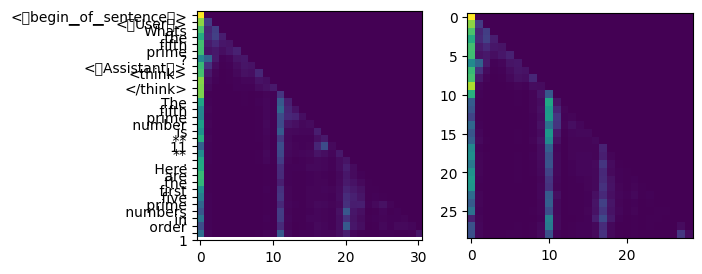

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


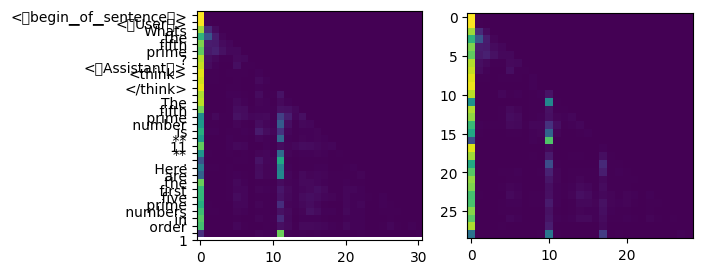

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


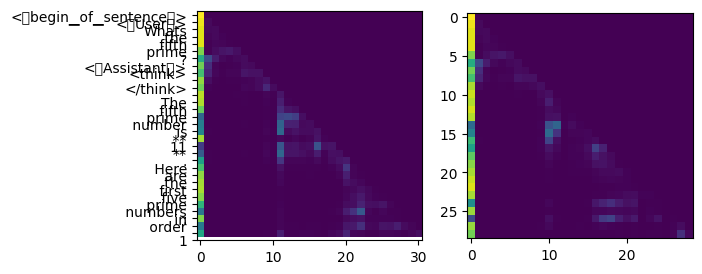

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


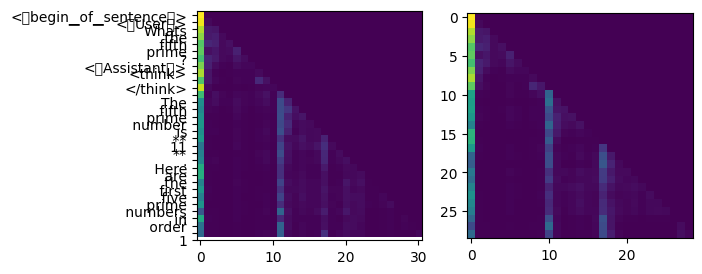

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


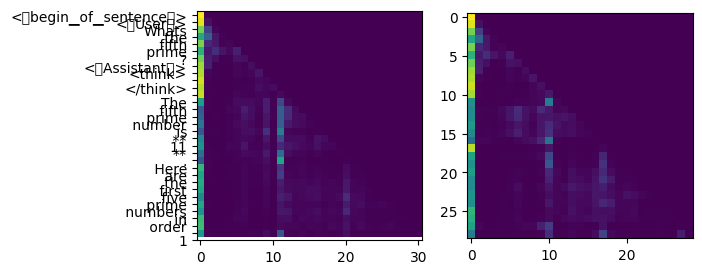

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


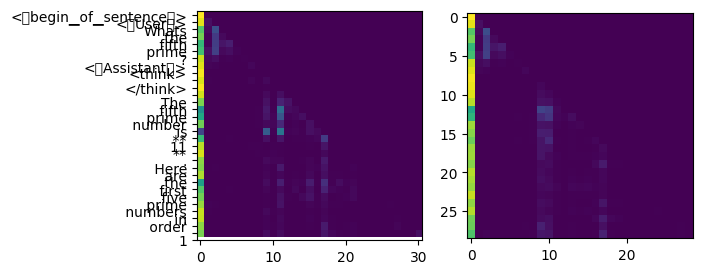

In [144]:

for h in heads[:10]:
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(out['attention_weights'][h])
    ax[1].imshow(out_r['attention_weights'][h])
    ax[0].set_yticks(range(len(out['tokens'])), out['tokens'])
    plt.show()

In [135]:
prompt_r = format_prompt(model, "Whats the fifth prime?", "reason")

# 2. Run generation + attention capture
out_r = generate_with_attention(
    model,
    prompt_r,
    heads=heads[:10],
    max_new_tokens=20,
    do_sample=False
)

100%|██████████| 20/20 [00:11<00:00,  1.67it/s]


In [140]:
prompt_r

'<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\n'

In [142]:
''.join(out_r['tokens'])

"<｜begin▁of▁sentence｜><｜User｜>Whats the fifth prime?<｜Assistant｜><think>\nTo determine the fifth prime number, I'll start by listing the prime numbers in order.\n\nFirst,"

In [139]:
out_r['tokens'][10], out['tokens'][11]

('To', '\n\n')

huh

based on the below plots, it looks like these heads either attend to \n\n if we're in answer mode

or 

if we're in reason mode, these attend to the the first reasoning token following \n 

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


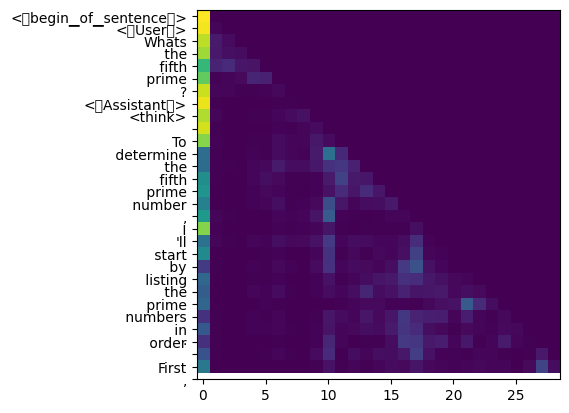

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


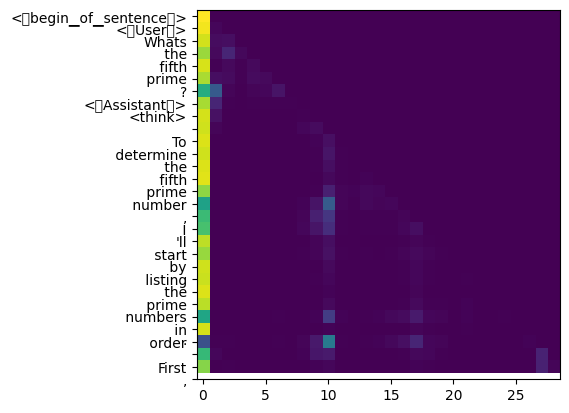

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


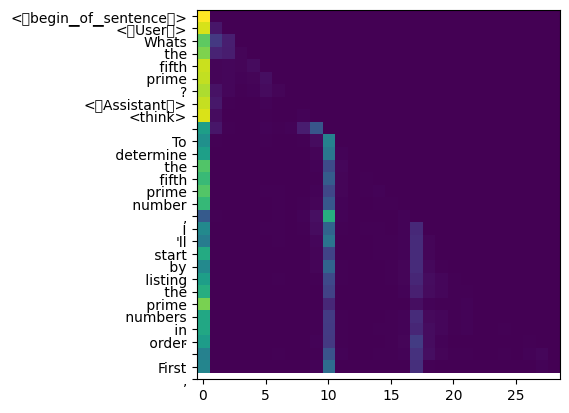

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


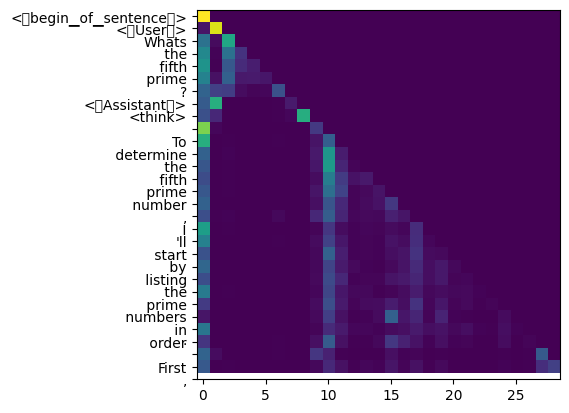

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


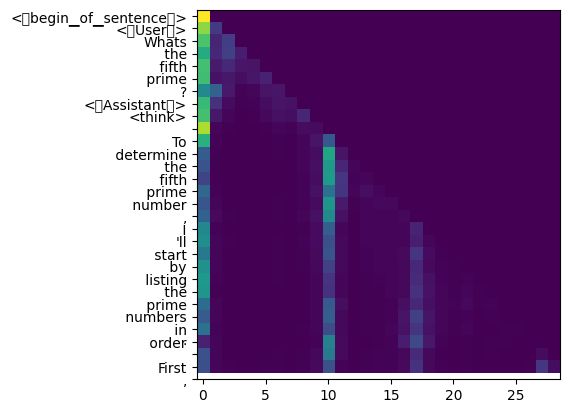

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


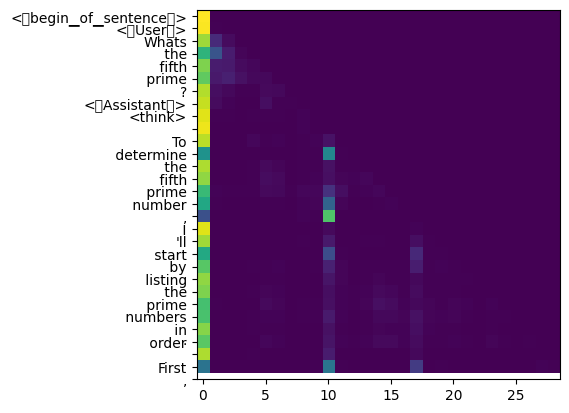

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


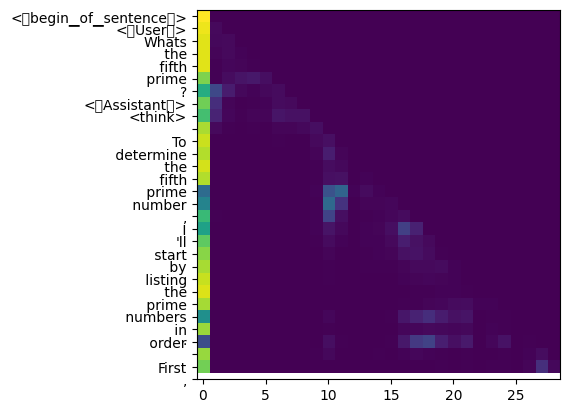

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


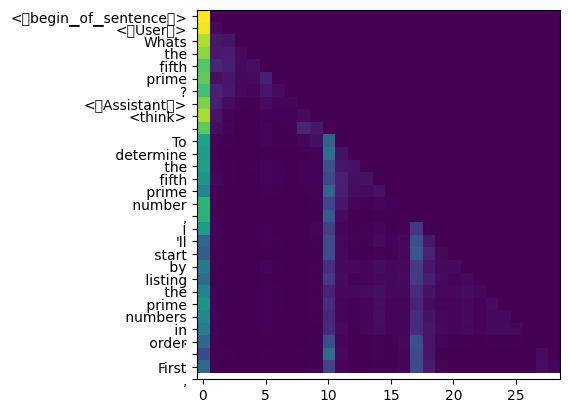

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


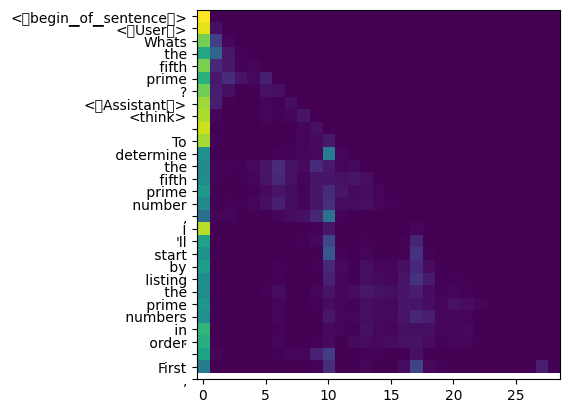

/Users/sda1048/Desktop/reasoning_research/reasoning_vector_research/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


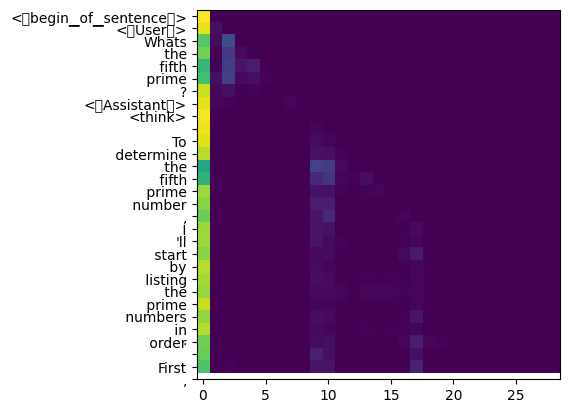

In [136]:
for h in heads[:10]:
    plt.imshow(out_r['attention_weights'][h])
    plt.yticks(range(len(out_r['tokens'])), out_r['tokens'])
    plt.show()

In [ ]:
reason_knob_values = np.linspace(0, 5, 10)
output_file = "reason_prompt_answer_vector_sweep.pkl"
collection = []
lengths = []

# Run sweep using nested rep then knob_value loops
for rep in range(1):
    for knob_value in reason_knob_values:
        current_out = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=1.0,
            injection_tensor = knob_value*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
            temp=None,
        )
        length = len(model.to_str_tokens(current_out))
        lengths.append(length)
        collection.append(current_out)

print(f"Results saved to {output_file}")

In [60]:
out = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=5,
            injection_tensor=final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
            temp=None,
        )

 18%|█▊        | 184/1000 [00:44<03:15,  4.18it/s]


In [61]:
out2 = simple_patch_generate(
            patch_prompt=reason_prompt,
            target_heads=[(2, 17)],
            base_prompt=None,
            max_new_tokens=1000,
            scale=1,
            injection_tensor=5*final_nn_values['vector']/final_nn_values['vector'].norm(dim=0),
            temp=None,
        )

  1%|          | 9/1000 [00:02<03:47,  4.36it/s]


In [55]:
out

"<｜User｜>Whats the fifth prime?<｜Assistant｜><think>\nTo determine the fifth prime number, I'll start by listing the prime numbers in order.\n\nFirst, I know that 2 is the smallest and only even prime number.\n\nNext, 3 is the second prime number.\n\nThen, 5 comes after 3 as the third prime.\n\nAfter that, 7 is the fourth prime number.\n\nFinally, 11 is the fifth prime number.\n</think>\n\nTo find the **fifth prime number**, let's list the prime numbers in order until we reach the fifth one.\n\n1. **2** - The first prime number.\n2. **3** - The second prime number.\n3. **5** - The third prime number.\n4. **7** - The fourth prime number.\n5. **11** - The fifth prime number.\n\nSo, the **fifth prime number** is:\n\n\\[\n\\boxed{11}\n\\]"

In [56]:
"</think>" in out

True